# Payload-Based Initial Mass Optimization

This example shows how to use `payload=` to let OpenTOP optimize the initial mass. When `payload` is provided, `m0` is used only as the initial guess; the actual initial mass is bounded between `OEW + payload` and the feasible maximum mass.

In [1]:
import warnings

import matplotlib.pyplot as plt

import opentop as top
import pandas as pd

warnings.filterwarnings("ignore", message="Warning: Wave drag is experimental")
from opentop.plotting import apply_publication_style  # noqa: E402

apply_publication_style()

## Flight Setup

Without `payload`, `m0` fixes the initial mass. With `payload`, `m0` is only an initial guess and the optimizer chooses the initial mass needed for the flight.

In [2]:
actype = "A320"
origin = "EHAM"
destination = "LEMD"

m0 = 0.85
payload = 10_000.0  # kg
nodes = 15
max_iter = 800

In [3]:
def run_case(cls, *, payload=None):
    opt = cls(actype, origin, destination, m0=m0, payload=payload)
    opt.setup(nodes=nodes, max_iter=max_iter)
    df = opt.trajectory(objective="fuel")
    return opt, df


def along_track_distance_km(df):
    if "distance" in df.columns:
        return df.distance / 1000
    segment_m = (df.x.diff().fillna(0) ** 2 + df.y.diff().fillna(0) ** 2) ** 0.5
    return segment_m.cumsum() / 1000


def summarize(label, opt, df):
    dry_payload_mass = opt.oew + (opt.payload or 0.0)
    return {
        "case": label,
        "success": opt.success,
        "status": opt.stats["return_status"],
        "initial_mass_kg": df.mass.iloc[0],
        "final_mass_kg": df.mass.iloc[-1],
        "fuel_burn_kg": df.mass.iloc[0] - df.mass.iloc[-1],
        "estimated_fuel_onboard_kg": df.mass.iloc[0] - dry_payload_mass,
        "flight_time_min": df.ts.iloc[-1] / 60,
        "max_altitude_ft": df.altitude.max(),
    }

## Cruise Example

In [4]:
cruise_fixed, cruise_fixed_df = run_case(top.Cruise)
cruise_payload, cruise_payload_df = run_case(top.Cruise, payload=payload)

pd.DataFrame(
    [
        summarize("cruise: fixed m0", cruise_fixed, cruise_fixed_df),
        summarize("cruise: payload optimized", cruise_payload, cruise_payload_df),
    ]
)

/home/junzi/arc/code/1-public/opentop/opentop/cruise.py:40: UserWarning: payload is provided; m0 is used only as the initial mass guess and does not fix the initial mass.
  super().__init__(


,case,success,status,initial_mass_kg,final_mass_kg,fuel_burn_kg,estimated_fuel_onboard_kg,flight_time_min,max_altitude_ft
0,cruise: fixed m0,True,Solve_Succeeded,66299.999901,61587.037907,4712.961994,23699.999901,104.730980,35072.0
1,cruise: payload optimized,True,Solve_Succeeded,56600.923280,52599.999902,4000.923378,4000.923280,104.610898,40013.0


The payload case has a bounded initial mass decision variable. The bounds are visible after `init_conditions()` or after solving.

In [5]:
{
    "minimum_mass_kg": cruise_payload.mass_min,
    "initial_mass_lower_bound_kg": cruise_payload.mass_init_lb,
    "initial_mass_upper_bound_kg": cruise_payload.mass_init_ub,
    "m0_initial_guess_kg": cruise_payload.mass_init,
    "optimized_initial_mass_kg": cruise_payload_df.mass.iloc[0],
}

{'minimum_mass_kg': 52600.0,
 'initial_mass_lower_bound_kg': 52600.0,
 'initial_mass_upper_bound_kg': 76810.0,
 'm0_initial_guess_kg': 66300.0,
 'optimized_initial_mass_kg': np.float64(56600.923279707786)}

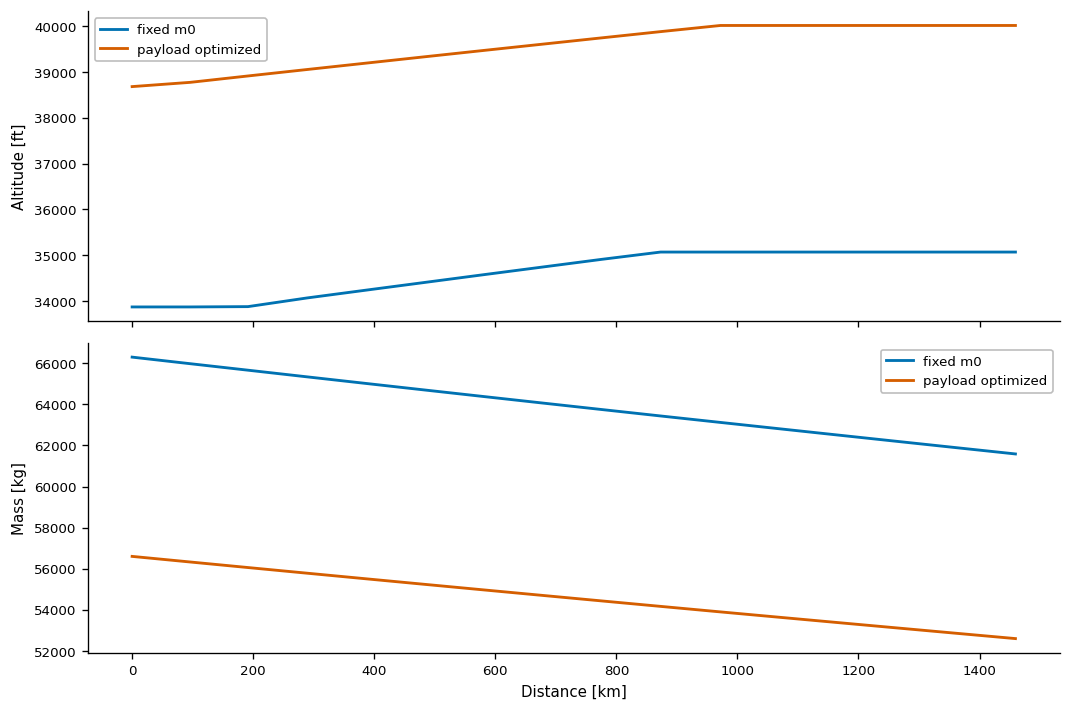

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for label, df in {
    "fixed m0": cruise_fixed_df,
    "payload optimized": cruise_payload_df,
}.items():
    distance_km = along_track_distance_km(df)
    axes[0].plot(distance_km, df.altitude, label=label)
    axes[1].plot(distance_km, df.mass, label=label)

axes[0].set_ylabel("Altitude [ft]")
axes[1].set_ylabel("Mass [kg]")
axes[1].set_xlabel("Distance [km]")
axes[0].legend()
axes[1].legend()
fig.tight_layout()

## CompleteFlight Example

The same `payload=` behavior is available for `CompleteFlight`.

In [7]:
full_fixed, full_fixed_df = run_case(top.CompleteFlight)
full_payload, full_payload_df = run_case(top.CompleteFlight, payload=payload)

pd.DataFrame(
    [
        summarize("complete flight: fixed m0", full_fixed, full_fixed_df),
        summarize("complete flight: payload optimized", full_payload, full_payload_df),
    ]
)

/home/junzi/arc/code/1-public/opentop/opentop/full.py:38: UserWarning: payload is provided; m0 is used only as the initial mass guess and does not fix the initial mass.
  super().__init__(


,case,success,status,initial_mass_kg,final_mass_kg,fuel_burn_kg,estimated_fuel_onboard_kg,flight_time_min,max_altitude_ft
0,complete flight: fixed m0,True,Solve_Succeeded,66299.999901,60965.172400,5334.827501,23699.999901,120.171420,35893.0
1,complete flight: payload optimized,True,Solve_Succeeded,57293.421175,52599.999902,4693.421273,4693.421175,121.220962,40263.0


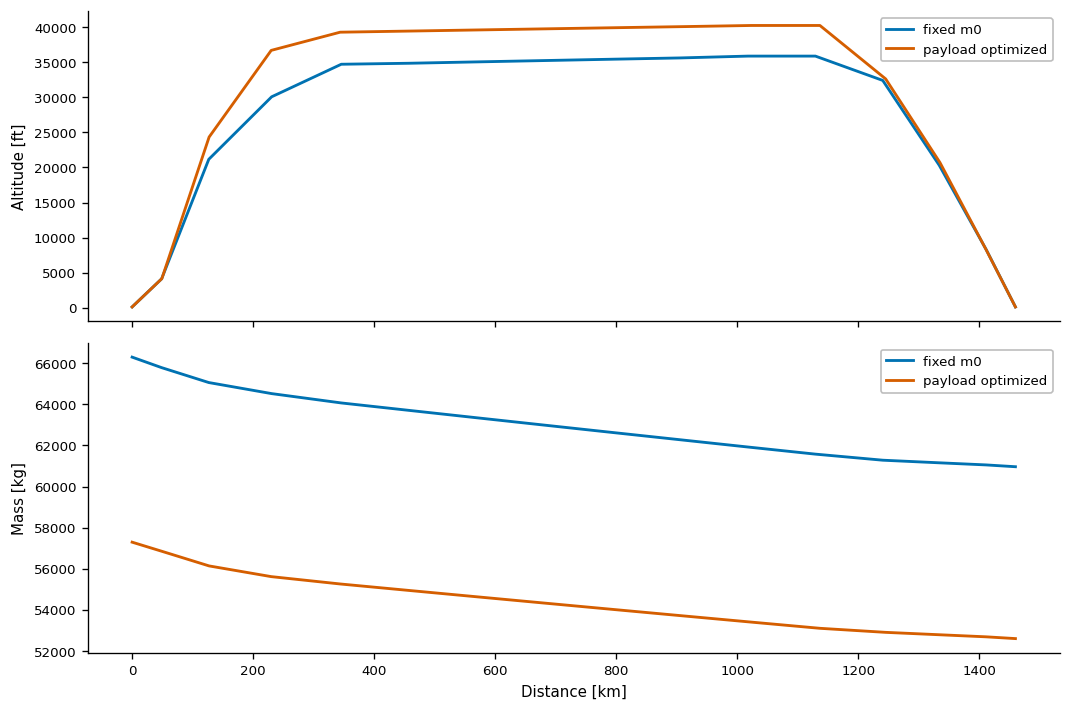

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for label, df in {
    "fixed m0": full_fixed_df,
    "payload optimized": full_payload_df,
}.items():
    distance_km = along_track_distance_km(df)
    axes[0].plot(distance_km, df.altitude, label=label)
    axes[1].plot(distance_km, df.mass, label=label)

axes[0].set_ylabel("Altitude [ft]")
axes[1].set_ylabel("Mass [kg]")
axes[1].set_xlabel("Distance [km]")
axes[0].legend()
axes[1].legend()
fig.tight_layout()